In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
np.set_printoptions(legacy='1.25')

h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [3]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [4]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = np.unique(magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1))

print(np.array(btunes))
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]


mj1_0s, mj2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


mj1_1s, mj2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=mj1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=mj2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=mj1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=mj2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))
print(ket1_1basis.kets)

[ 4.44616645  5.94607803  8.94590118 18.26678025]
[KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Rb:58,P_1/2,1/2)]


In [20]:
b_index = 1

# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets:
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[1]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(ket_tuples)


4
((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2)))


In [ ]:
# setting target and resonant states
ket_tuples = [tuple0, tuple1]
# ket_tuples = []
# for tuple0 in ket0_tuples:
#     for tuple1 in ket1_tuples:
#         ket_tuples.append(tuple0)
#         ket_tuples.append(tuple1)

eff_system = pi.EffectiveSystemPair(ket_tuples)
# eff_system.set_minimum_number_of_ket_pairs(1)
# eff_system.set_maximum_number_of_ket_pairs(10)
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
bs = np.linspace(4, 20, 400)

print(bs)

eff_h = eff_system.get_effective_hamiltonian(unit="MHz")
# eff_h -= np.eye(2) * eff_system.get_pair_energies("MHz")[1]




thetaList = np.linspace(0, 360, 100)
r = 25

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\angular\\2x2 Hams\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)
    


for mag in bs:
    if not os.path.exists(datapath + f'{n1_0}{n2_0} m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {mag}.csv'):
        eff_h_dict_elements = {'theta' : thetaList, '00' : [], '01' : [], '10' : [], '11' : []}

        eff_system.set_magnetic_field([0,0,mag], unit='G')
        pair_energy_pm = eff_system.get_pair_energies("MHz")[0]

        # for each theta
        for theta in thetaList:
            eff_system.set_distance(r, theta, "micrometer")
            eff_system.set_maximum_number_of_ket_pairs(0)
            H = eff_system.get_effective_hamiltonian(unit="MHz") - pair_energy_pm * np.eye(2)
            eff_h_dict_elements["00"].append(H[0,0])
            eff_h_dict_elements["01"].append(H[0,1])
            eff_h_dict_elements["10"].append(H[1,0])
            eff_h_dict_elements["11"].append(H[1,1])

        pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'{n1_0}{n2_0} m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {mag}.csv', index=False)
            # print(eff_system.get_effective_hamiltonian(unit="MHz"))


[ 4.          4.04010025  4.0802005   4.12030075  4.160401    4.20050125
  4.2406015   4.28070175  4.32080201  4.36090226  4.40100251  4.44110276
  4.48120301  4.52130326  4.56140351  4.60150376  4.64160401  4.68170426
  4.72180451  4.76190476  4.80200501  4.84210526  4.88220551  4.92230576
  4.96240602  5.00250627  5.04260652  5.08270677  5.12280702  5.16290727
  5.20300752  5.24310777  5.28320802  5.32330827  5.36340852  5.40350877
  5.44360902  5.48370927  5.52380952  5.56390977  5.60401003  5.64411028
  5.68421053  5.72431078  5.76441103  5.80451128  5.84461153  5.88471178
  5.92481203  5.96491228  6.00501253  6.04511278  6.08521303  6.12531328
  6.16541353  6.20551378  6.24561404  6.28571429  6.32581454  6.36591479
  6.40601504  6.44611529  6.48621554  6.52631579  6.56641604  6.60651629
  6.64661654  6.68671679  6.72681704  6.76691729  6.80701754  6.84711779
  6.88721805  6.9273183   6.96741855  7.0075188   7.04761905  7.0877193
  7.12781955  7.1679198   7.20802005  7.2481203   7.

In [21]:
H = {f'{mag}' : pd.read_csv(datapath + f'{n1_0}{n2_0} m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {mag}.csv') for mag in bs}
print(H)
matrix_lists = {f'{mag}' : [[[H[f'{mag}']['00'][i], H[f'{mag}']['01'][i]], [H[f'{mag}']['10'][i], H[f'{mag}']['11'][i]]] for i in range(len(H[f'{mag}']))] for mag in bs}

eval_list = {f'{mag}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{mag}']] for mag in bs}
evec_list = {f'{mag}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{mag}']] for mag in bs}
Thetas = {f'{mag}' : H[f'{mag}']['theta'] for mag in bs}

{'4.0':          theta        00        01        10        11
0     0.000000  0.002544  0.000000  0.000000 -5.439324
1     3.636364  0.002553 -0.014480 -0.014480 -5.439298
2     7.272727  0.002582 -0.028728 -0.028728 -5.439222
3    10.909091  0.002648 -0.042513 -0.042513 -5.439099
4    14.545455  0.002772 -0.055614 -0.055614 -5.438935
..         ...       ...       ...       ...       ...
95  345.454545  0.002772  0.055614  0.055614 -5.438935
96  349.090909  0.002648  0.042513  0.042513 -5.439099
97  352.727273  0.002582  0.028728  0.028728 -5.439222
98  356.363636  0.002553  0.014480  0.014480 -5.439298
99  360.000000  0.002544  0.000000  0.000000 -5.439324

[100 rows x 5 columns], '4.040100250626566':          theta        00        01        10        11
0     0.000000  0.002566  0.000000  0.000000 -5.327320
1     3.636364  0.002575 -0.014482 -0.014482 -5.327294
2     7.272727  0.002607 -0.028730 -0.028730 -5.327217
3    10.909091  0.002678 -0.042517 -0.042517 -5.327094
4    14.545

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2))
{'4.0': {'state0': [-5.439323902130127, -5.439336684187744, -5.439373273818675, -5.439431181806198, -5.439503597096819, -5.43958394195765, -5.439663028799308, -5.439732107231106, -5.439781955321852, -5.4398043705376455, -5.439792168244394, -5.439740227621705, -5.439645852345443, -5.439509103308891, -5.439332113563611, -5.43912022841344, -5.438880684720768, -5.438623383496343, -5.438359748288752, -5.438100920121922, -5.437859652392564, -5.437646924196006, -5.437473363522006, -5.437347688700695, -5.437275333973031, -5.437260890661419, -5.437304390309974, -5.437403850287002, -5.4375547882612665, -5.437748837521234, -5.437977391828996, -5.438229264826707, -5.438491840322174, -5.438753731160141, -5.439003390809806, -5.43922979288555, -5.439425103358531, -5.439582847159301, -5.439698424649862, -5.439771467557741, -5.439802869789797, -5.439796986796215, -5.439759732756126, -5.43969

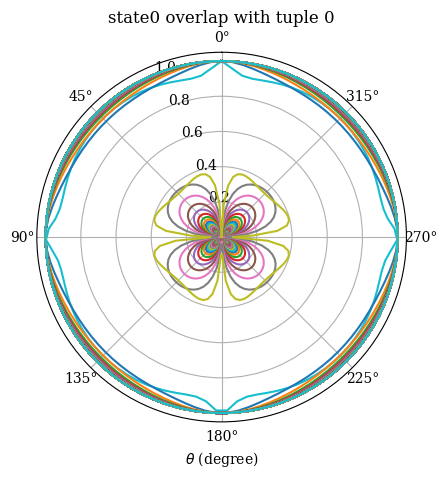

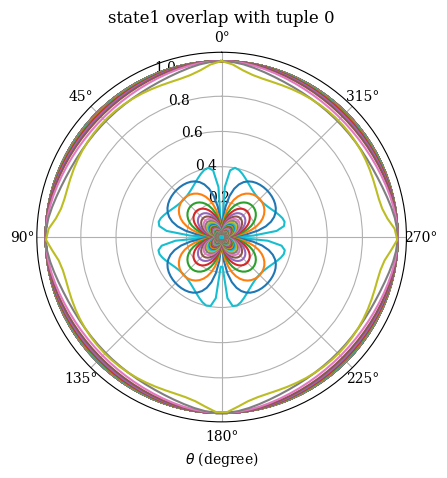

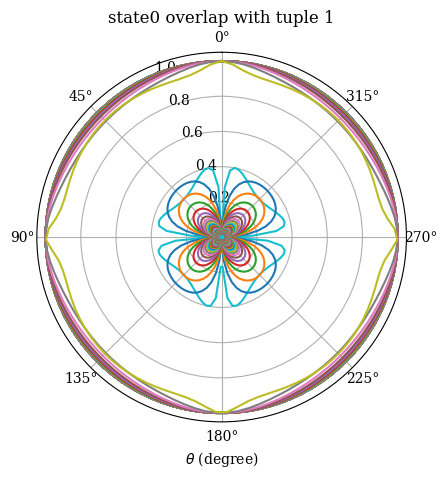

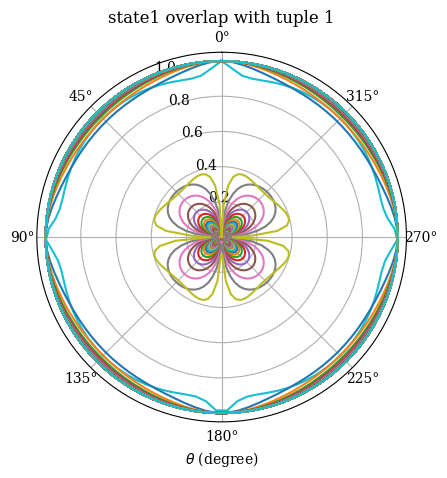

NameError: name 'thetaList' is not defined

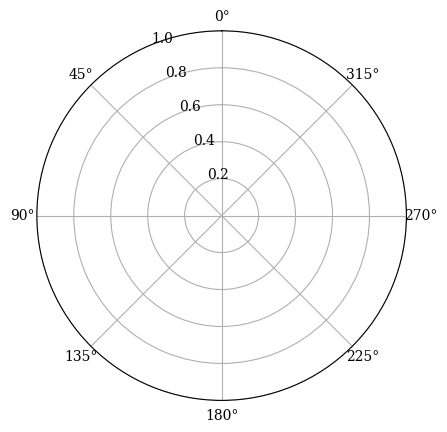

In [22]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\angular\\single channel\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\Hams\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

Ediags = {f'{mag}' : {
    'state0' : [eval[0] for eval in eval_list[f'{mag}']],
    'state1' : [eval[1] for eval in eval_list[f'{mag}']]
} for mag in bs}
print(Ediags)
tup0_overlaps0 = {f'{mag}' : [abs(np.dot([1,0], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps1 = {f'{mag}' : [abs(np.dot([0,1], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup0_overlaps1 = {f'{mag}' : [abs(np.dot([1,0], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps0 = {f'{mag}' : [abs(np.dot([0,1], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}

print(tup1_overlaps1)

# state0 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps0[f'{mag}'], label = f'{mag}G') 
ax.set_title('state0 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlap {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index0.png')
plt.show() 

# state1 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlap {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index1.png')
plt.show()    

# state0 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps0[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state0 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlap {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index0.png')
plt.show()  

# state1 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlap {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index1.png')
plt.show()



ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state0']), "-", label= f'state0 {round(mag, 2)}G')
# plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> {tuple1[0]} {tuple1[1]}')
plt.savefig(figpath + f'\\eigenenergies {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index0.png')
plt.show()


ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:   
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state1']), "-", label= f'state1 {round(mag, 2)}G')
    # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
# plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> {tuple1[0]} {tuple1[1]}')

plt.savefig(figpath + f'\\eigenenergies {n1_0} {n2_0} mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index1.png')
plt.show()

In [ ]:
r=25
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
bs = np.linspace(4, 20, 400)
bs=bs[:int(len(bs)/2)]
zeemandatapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channel zeemans\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\to {orbs[l1_1]}{orbs[l2_1]}\\'

energies0 = pd.read_csv(zeemandatapath + f'{n1_0, n2_0}, index0')
energies1 = pd.read_csv(zeemandatapath + f'{n1_1, n2_1}, index1')
print(energies1)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\angular\\2x2 Hams\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'
fig = plt.figure(figsize=(5,5))
ax=[]
x_tick_labels = [f'{ket1.m}, {ket2.m}', f'{ket1_1.m}, {ket2_1.m}' ]

ax.append(fig.add_axes([.2, .1, .6, .3]))
ax.append(fig.add_axes([.1, .45, .5, .5], projection='polar'))
ax.append(fig.add_axes([.8, .45, .05, .5]))


t0 = 1
x0 = np.linspace(t0-.4, t0+.4, 2)
thetas = np.linspace(0, 2*np.pi)
t1 = 2
x1 = np.linspace(t1-.4, t1+.4, 2)

ax[0].set_xlabel(r'$m_{j,A}, m_{j,B}$')
ax[0].set_ylabel(f"Energy ({energy_unit})")
ax[0].set_xticks([t0, t1])
ax[0].set_xticklabels(x_tick_labels, fontsize=15)
# ax[0].set(ylim=[min(np.array([energies0, energies1]).flatten()), max(np.array([energies0, energies1]).flatten())])
ax[0].set(ylim=[-40, 10])


ax[2].margins(0, 0)
ax[1].set_theta_zero_location("N")

xdef = 1.5 * np.ones(2)

ax[1].set_rmax(1.5)
ax[1].set_rmin(0)
def R_c(c3k, delta):
    return (c3k/delta)**(1/3)

# ax.legend()
# plt.show()
artists = []
for i, mag in enumerate(bs):
    containers = []

    for mj1_1 in mj1_1s:
        for mj2_1 in mj2_1s:
            H = {f'{mag}' : pd.read_csv(datapath + f'{n1_0}{n2_0} m0s({-1/2,-1/2}), m1s({mj1_1,mj2_1}), sep {r}um, mag {mag}.csv') for mag in bs}
            print(H)
            matrix_lists = {f'{mag}' : [[[H[f'{mag}']['00'][i], H[f'{mag}']['01'][i]], [H[f'{mag}']['10'][i], H[f'{mag}']['11'][i]]] for i in range(len(H[f'{mag}']))] for mag in bs}
            evec_list = {f'{mag}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{mag}']] for mag in bs}
            Thetas = {f'{mag}' : H[f'{mag}']['theta'] for mag in bs}
            tup0_overlaps0 = {f'{mag}' : [abs(np.dot([0,1], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}
            print(tup1_overlaps0[f'{mag}'])
            line0 = ax[1].plot(np.radians(Thetas[f'{mag}']), tup1_overlaps0[f'{mag}'], label=f'0', c='0', linewidth = 2)
            line1 = ax[0].plot(x1, energies1[f'mjs1{mj1_1}{mj2_1}'][i] * np.ones_like(x1), c='0')
            containers += line0 + line1
    
    # linedef = ax[0].plot(xdef, [energies0[i], energies1[i]], c='b')
    line2 = ax[0].plot(x0, energies0[f'mjs0{-1/2}{-1/2}'][i] * np.ones_like(x0), c='0')
    bplot = ax[2].bar(0, bs[i], color='orange', width=1)

    # annotate = ax.annotate("",
    #         xy=(xdef, energies1[0]),xytext=(xdef, energies0[1]), textcoords='data',
    #         arrowprops=dict(arrowstyle="<->",
    #                         connectionstyle="arc3", color='r', lw=2),
    #         )

    # circle = ax[1].plot(thetas, R_c(c['c3k'], abs(energies0[i] - energies1[i])) * np.ones_like(thetas), color = 'r')
    # circ = plt.Circle((0, 0), R_c(c['c3k'], abs(energies0[i] - energies1[i])), color='r', fill=False)
    # circle = [ax[1].add_patch(circ)]
    # print(line0)
    containers += line2 + [bar for bar in bplot.patches]
    # print(containers)

    artists.append(containers)
print(bplot)
# artists = np.array(artists).flatten()
print(np.shape(artists))
# ax[1].scatter(0,0, c='r')
# ax[1].scatter(0,3, c='b')
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval = 80)
print(ani)
plt.show()
ani.save(filename= fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\anim\\overlap1.gif', writer='pillow')

     Unnamed: 0  mjs1-0.5-0.5  mjs1-0.50.5  mjs10.5-0.5  mjs10.50.5
0             0    -20.374568   -16.646550   -16.646464  -12.918447
1             1    -20.412318   -16.646927   -16.646838  -12.881447
2             2    -20.450072   -16.647307   -16.647215  -12.844450
3             3    -20.487830   -16.647691   -16.647596  -12.807458
4             4    -20.525592   -16.648079   -16.647981  -12.770469
..          ...           ...          ...          ...         ...
395         395    -35.583133   -17.090990   -17.080473    1.411669
396         396    -35.622400   -17.092874   -17.082294    1.447232
397         397    -35.661671   -17.094762   -17.084117    1.482792
398         398    -35.700947   -17.096654   -17.085945    1.518348
399         399    -35.740226   -17.098550   -17.087776    1.553900

[400 rows x 5 columns]
{'4.0':          theta            00        01        10        11
0     0.000000 -4.768372e-07  0.152711  0.152711 -9.164588
1     3.636364  7.677078e-05  0.15

In [19]:
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval = 80)
print(ani)
plt.show()
ani.save(filename= fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\anim\\overlap.gif', writer='pillow')

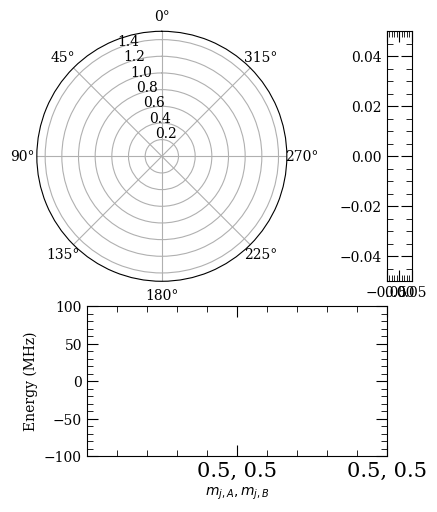

In [ ]:
r=25
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
bs = np.linspace(0, max(btunes), 100)


fig = plt.figure(figsize=(5,5))
ax=[]
x_tick_labels = [f'{ket1.m}, {ket2.m}', f'{ket1_1.m}, {ket2_1.m}' ]

ax.append(fig.add_axes([.2, .1, .6, .3]))
ax.append(fig.add_axes([.1, .45, .5, .5], projection='polar'))
ax.append(fig.add_axes([.8, .45, .05, .5]))


t0 = 1
x0 = np.linspace(t0-.4, t0+.4, 2)
thetas = np.linspace(0, 2*np.pi)
t1 = 2
x1 = np.linspace(t1-.4, t1+.4, 2)

ax[0].set_xlabel(r'$m_{j,A}, m_{j,B}$')
ax[0].set_ylabel(f"Energy ({energy_unit})")
ax[0].set_xticks([t0, t1])
ax[0].set_xticklabels(x_tick_labels, fontsize=15)
# ax[0].set(ylim=[min(np.array([energies0, energies1]).flatten()), max(np.array([energies0, energies1]).flatten())])
ax[0].set(ylim=[-150, 50])


ax[2].margins(0, 0)
ax[1].set_theta_zero_location("N")

xdef = 1.5 * np.ones(2)

ax[1].set_rmax(1.5)
ax[1].set_rmin(0)
# for i, mag in enumerate(bs):
#     bplot = ax[2].bar(0, bs[i], color='orange', width=1)

#     artists[i] += + [bar for bar in bplot.patches]
    

In [44]:
print(artists)
ani = animation.ArtistAnimation(fig=fig, artists=artists[:int(len(artists)/2)], interval = 200)
print(ani)
plt.show()
ani.save(filename= fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\anim.gif', writer='pillow')

[[<matplotlib.lines.Line2D object at 0x000002620C1AF4D0>, <matplotlib.lines.Line2D object at 0x000002620C1AF0E0>, <matplotlib.lines.Line2D object at 0x000002620C1AF230>, <matplotlib.lines.Line2D object at 0x000002620B915160>, <matplotlib.lines.Line2D object at 0x00000262112ABE00>, <matplotlib.lines.Line2D object at 0x00000262112ABCB0>, <matplotlib.lines.Line2D object at 0x00000262112ABB60>, <matplotlib.lines.Line2D object at 0x00000262112ABA10>, <matplotlib.lines.Line2D object at 0x00000262112AB8C0>, <matplotlib.patches.Rectangle object at 0x000002620D429950>], [<matplotlib.lines.Line2D object at 0x00000262112AB770>, <matplotlib.lines.Line2D object at 0x00000262112AA660>, <matplotlib.lines.Line2D object at 0x00000262112AB230>, <matplotlib.lines.Line2D object at 0x00000262112AB380>, <matplotlib.lines.Line2D object at 0x00000262112AB4D0>, <matplotlib.lines.Line2D object at 0x00000262112AAF90>, <matplotlib.lines.Line2D object at 0x00000262112AB0E0>, <matplotlib.lines.Line2D object at 0x00